# Third Question
Which categories of problems are most common across the city?

This is another example question but it woke my intrest, so wanted to answer it.

### Workflow
1. Identify needed Attributes
2. Make plan
3. Code

### 1. Attributes/Data needed

ZuriWieNeu dataset:
| Name | Definition |
|------|------------|
| GEOMETRIE | Geometriefeld. Typ SHAPE. |
| SERVICE_CODE | Kategorie [Abfall/Sammelstelle, Beleuchtung Uhren, Graffiti, Signalisation/Lichtsignal, Grünflächen/Spielplätze, Strasse/Trottoir/Platz, Brunnen/Hydranten, VBZ/ÖV]. Typ STRING. |

Quartiere dataset:
| Name | Definition |
|------|------------|
| GEOMETRIE | Geometriefeld |
| NAME | Bezeichnung des statistischen Quartiers |

### 2. Plan
- Reuse as much code as possible from previous questions
- First find the most common category for the entire city
- Adapt the code for the entire city to the neighbourhoods

### 3. Code

In [ ]:
# Load Librarys
import pandas as pd
import geopandas as gpd 
import numpy as np
import matplotlib.pyplot as plt

# Load data
data_gpkg = gpd.read_file("../data/raw/ZuriWieNeu_gpkg_data/data.gpkg").to_crs(epsg=2056)
boundaries_gpkg_v = gpd.read_file("../data/raw/boundaries_GPKG/data.gpkg",
 layer="stzh.adm_statistische_quartiere_v").to_crs(epsg=2056) # Layer for mapping

# Filter data
data_subset = data_gpkg[["geometry", "service_code"]]
boundaries_subset = boundaries_gpkg_v[["geometry", "qname"]]

# Overview
display(data_subset.head(1))
display(boundaries_subset.head(1))
print("Categories:")
print(data_subset["service_code"].unique())

,geometry,service_code
0,POINT (2678968 1247548),Strasse/Trottoir/Platz


,geometry,qname
0,"POLYGON ((2680606.662 1247034.584, 2680626.356...",Alt-Wiedikon


Categories:
<ArrowStringArray>
[   'Strasse/Trottoir/Platz',       'Abfall/Sammelstelle',
   'Grünflächen/Spielplätze',         'Beleuchtung/Uhren',
                  'Graffiti', 'Signalisation/Lichtsignal',
         'Brunnen/Hydranten',                    'VBZ/ÖV',
                 'Allgemein',                'Schädlinge']
Length: 10, dtype: str


### First for the hole city 

In [6]:
# Count Numbers of reports per category
category_counts = data_subset["service_code"].value_counts()
print(category_counts)


service_code
Abfall/Sammelstelle          27583
Signalisation/Lichtsignal    11034
Strasse/Trottoir/Platz        9902
Grünflächen/Spielplätze       7288
Beleuchtung/Uhren             5424
Allgemein                     4007
Graffiti                      3808
VBZ/ÖV                        1893
Brunnen/Hydranten             1310
Schädlinge                     900
Name: count, dtype: int64


=> Most Reports in Zurich are about Trash and Trash collection (Abfall/Sammelstelle)

### Next for the individual neigbourhoods

In [ ]:
# Spatial Join: distribute points to neighbourhoods
joined = gpd.sjoin(data_subset, boundaries_subset, how= "left", predicate="within")

# Count Numbers of reports per neighbourhood per category
counts = (
    joined
    .groupby(["qname", "service_code"])
    .size()
    .reset_index(name="n_reports")
)

print(counts)


           qname               service_code  n_reports
0      Affoltern        Abfall/Sammelstelle        785
1      Affoltern                  Allgemein        109
2      Affoltern          Beleuchtung/Uhren        247
3      Affoltern          Brunnen/Hydranten         30
4      Affoltern                   Graffiti        133
..           ...                        ...        ...
335  Wollishofen    Grünflächen/Spielplätze        371
336  Wollishofen                 Schädlinge         95
337  Wollishofen  Signalisation/Lichtsignal        413
338  Wollishofen     Strasse/Trottoir/Platz        387
339  Wollishofen                     VBZ/ÖV         51

[340 rows x 3 columns]


In [12]:
# Calculate most common category per neighbourhood
most_common_per_neigh = (
    counts
    .sort_values("n_reports", ascending=False)
    .groupby("qname")
    .first()
    .reset_index()
)

print(most_common_per_neigh.head(7))


          qname            service_code  n_reports
0     Affoltern     Abfall/Sammelstelle        785
1   Albisrieden     Abfall/Sammelstelle        648
2  Alt-Wiedikon     Abfall/Sammelstelle       1286
3    Altstetten     Abfall/Sammelstelle       1412
4          City     Abfall/Sammelstelle        442
5          Enge     Abfall/Sammelstelle        699
6   Escher Wyss  Strasse/Trottoir/Platz        394


## Map

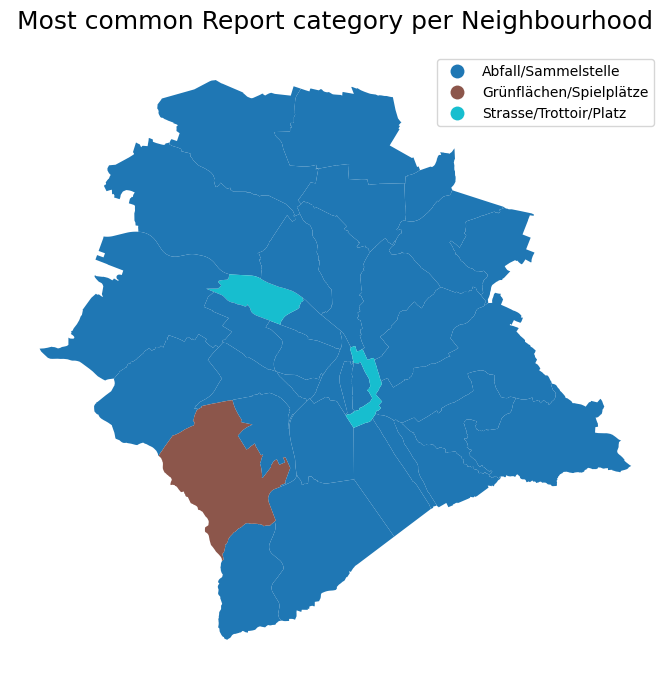

In [13]:
# Load data (map_layer)
boundaries_gpkg_map = gpd.read_file("../data/raw/boundaries_GPKG/data.gpkg", layer="stzh.adm_statistische_quartiere_map") # Layer for area calculation

# join table on qname
reports_map = pd.merge(boundaries_gpkg_map, most_common_per_neigh, left_on="qname", right_on="qname")

# plot
# Set up the Figure and Axes
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the choropleth map using the reports column
reports_map.plot(ax=ax, column="service_code", legend= True)

ax.set_title("Most common Report category per Neighbourhood", fontsize = 18)
ax.axis("off")

plt.show()

Which Neighbourhoods have not Abfall/Sammelstelle as their most common Report category?

In [14]:

not_blue = most_common_per_neigh[
    most_common_per_neigh["service_code"] != "Abfall/Sammelstelle"
]

print(not_blue)


          qname             service_code  n_reports
6   Escher Wyss   Strasse/Trottoir/Platz        394
8   Friesenberg  Grünflächen/Spielplätze        417
13  Hochschulen   Strasse/Trottoir/Platz        312
